In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
path = r"H:\Python\Etapa3\AnaliseTabela5\Tabela4.csv"

In [4]:
df = pd.read_csv(path, sep=";", skiprows=1, decimal=",", encoding="latin-1")

In [5]:
df.head()

,Sigla,Código,Estado,1991,2000,2010,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,AC,12,Acre,0.402,0.517,0.663,0.705,0.709,0.719,0.719,0.723,0.711,0.731,0.738,0.736,0.702,0.732,0.740,0.754
1,AL,27,Alagoas,0.370,0.471,0.631,0.657,0.653,0.670,0.669,0.680,0.682,0.694,0.693,0.694,0.691,0.722,0.739,0.746
2,AM,13,Amazonas,0.430,0.515,0.674,0.706,0.717,0.720,0.724,0.723,0.743,0.732,0.739,0.725,0.700,0.757,0.764,0.767
3,AP,16,Amapá,0.472,0.577,0.708,0.709,0.735,0.726,0.728,0.732,0.731,0.737,0.732,0.707,0.681,0.743,0.767,0.759
4,BA,29,Bahia,0.386,0.512,0.660,0.684,0.686,0.700,0.708,0.708,0.715,0.714,0.723,0.726,0.698,0.734,0.740,0.759


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sigla   27 non-null     str    
 1   Código  27 non-null     int64  
 2   Estado  27 non-null     str    
 3   1991    27 non-null     float64
 4   2000    27 non-null     float64
 5   2010    27 non-null     float64
 6   2012    27 non-null     float64
 7   2013    27 non-null     float64
 8   2014    27 non-null     float64
 9   2015    27 non-null     float64
 10  2016    27 non-null     float64
 11  2017    27 non-null     float64
 12  2018    27 non-null     float64
 13  2019    27 non-null     float64
 14  2020    27 non-null     float64
 15  2021    27 non-null     float64
 16  2022    27 non-null     float64
 17  2023    27 non-null     float64
 18  2024    27 non-null     float64
dtypes: float64(16), int64(1), str(2)
memory usage: 4.1 KB


In [7]:
# Remove colunas onde todos os valores são nulos (se houver)
df = df.dropna(how="all", axis=1)

In [8]:
# Ordenar de forma decrescente pelo ano de 2024
df_ordenado_2024 = df.sort_values(by="2024", ascending=False)
print(df_ordenado_2024[["Estado", "2024"]].head())


              Estado   2024
6   Distrito Federal  0.866
25         São Paulo  0.838
23    Santa Catarina  0.833
17            Paraná  0.822
18    Rio de Janeiro  0.819


In [9]:
# Calcular a diferença entre os dois anos
df["Melhora"] = df["2024"] - df["1991"]

# Encontrar o estado com a maior diferença
maior_melhora = df.sort_values(by="Melhora", ascending=False).iloc[0]
print(
    f"O estado com a maior melhora foi {maior_melhora['Estado']} com um aumento de {maior_melhora['Melhora']:.3f}"
)


O estado com a maior melhora foi Tocantins com um aumento de 0.428


In [10]:
# Verificar se alguma diferença é negativa
piorou = df[df["Melhora"] < 0]

if piorou.empty:
    print("Não, nenhum estado teve o IDH piorado entre 1991 e 2024.")
else:
    print("Estados que pioraram:")
    print(piorou[["Estado", "Melhora"]])


Não, nenhum estado teve o IDH piorado entre 1991 e 2024.


In [11]:
# Identificar colunas de anos (apenas dígitos)
anos = [c for c in df.columns if str(c).isdigit()]

# Colunas que ficam fixas como identificadores
id_vars = [c for c in df.columns if c not in anos and c != "Melhora"]

# Transformação para formato longo
df_longo = df.melt(
    id_vars=id_vars, value_vars=anos, var_name="Ano", value_name="IDH"
)

# Garantir a tipagem correta dos dados transformados
df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")


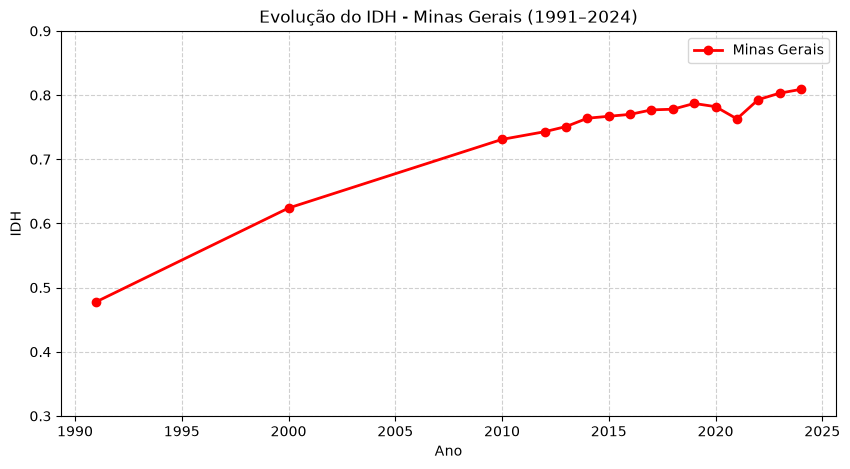

In [12]:
# Filtrar apenas o estado de Minas Gerais e ordenar cronologicamente
df_mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(
    df_mg["Ano"],
    df_mg["IDH"],
    marker="o",
    color="red",
    linewidth=2,
    label="Minas Gerais",
)

ax.set_title("Evolução do IDH - Minas Gerais (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.set_ylim(0.3, 0.9)
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend()
plt.show()


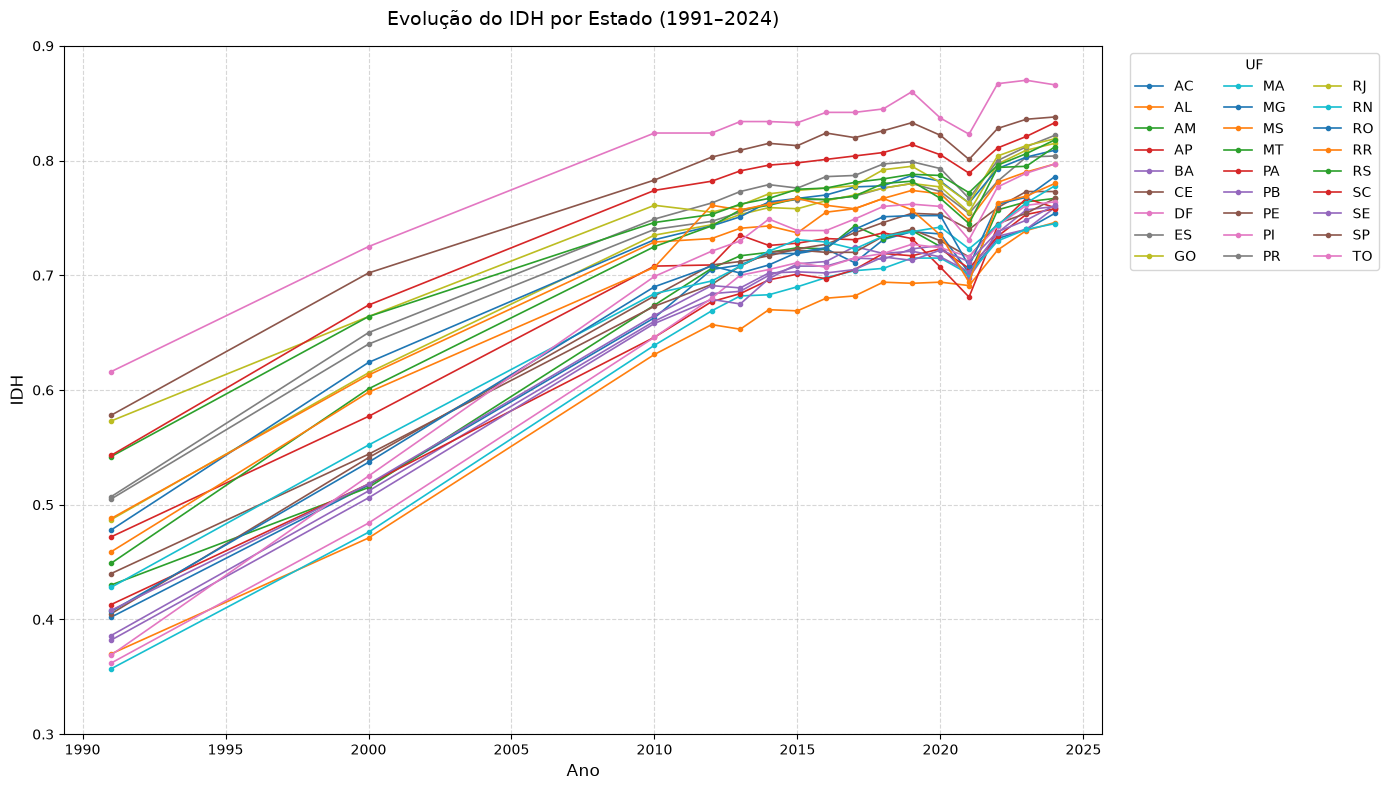

In [13]:
fig, ax = plt.subplots(figsize=(14, 8))

# Iterar sobre cada estado para gerar as linhas individuais
for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(
        grupo["Ano"],
        grupo["IDH"],
        marker="o",
        markersize=3,
        linewidth=1.2,
        label=sigla,
    )

ax.set_title("Evolução do IDH por Estado (1991–2024)", fontsize=14, pad=15)
ax.set_xlabel("Ano", fontsize=12)
ax.set_ylabel("IDH", fontsize=12)
ax.set_ylim(0.3, 0.9)
ax.grid(True, linestyle="--", alpha=0.5)

# Posiciona a legenda para fora do gráfico para não sobrepor as linhas
ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")

fig.tight_layout()
plt.show()
